# CCE Thermal Simulator — Examples

This notebook demonstrates the physics-based synthetic data generator for cold chain equipment (CCE) monitoring. It replaces the old database-dependent `RecordSetFactory` with a self-contained simulation.

In [1]:
import datetime as dt
import matplotlib.pyplot as plt
from utils.simulator import SimulatedRecordSet, default_config
from utils.device import MonitoringDeviceConfig, BaseRtmDevice

## 1. Low-level: SimulatedRecordSet

Generate a 24-hour batch directly from the simulator engine.

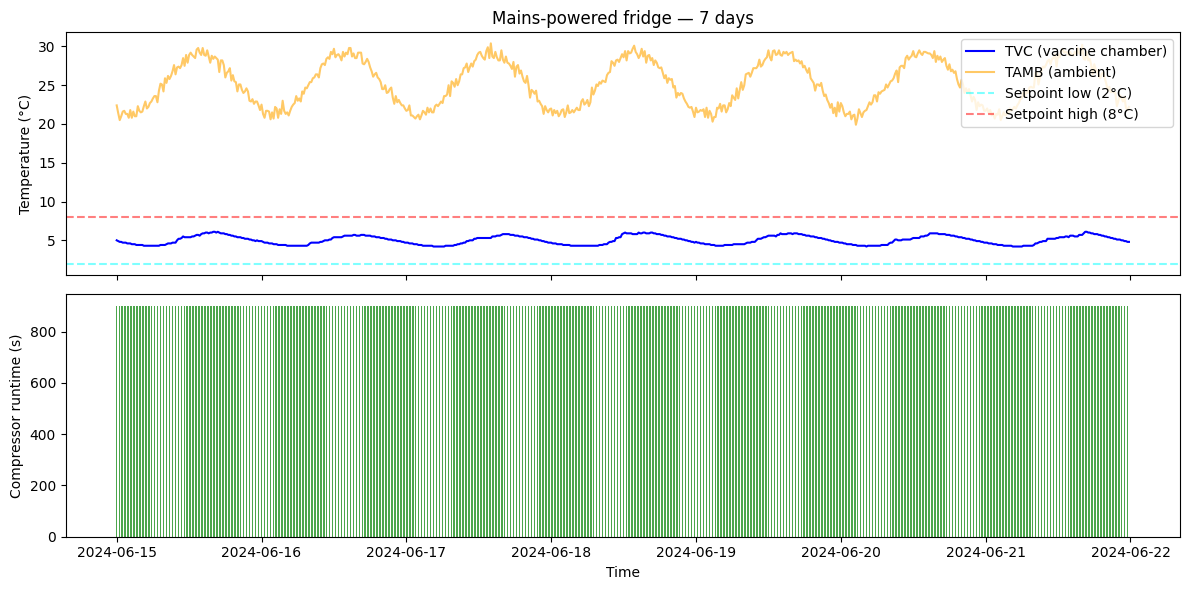

In [2]:
# Mains-powered fridge at latitude 12 (tropical)
config = default_config(power_type="mains", latitude=12.0)
config.sample_interval = 900  # 10-minute samples
sample_days = 7

start = dt.datetime(2024, 6, 15, 0, 0, 0)

batch_size = int(86400 / config.sample_interval * sample_days)  # * sample 7 days of data at 10-minute intervals
rs = SimulatedRecordSet.generate(config, batch_size=batch_size, start_time=start, interval=config.sample_interval)
# Extract time series
times = [r['ABST'] for r in rs.records]
tvcs = [r['TVC'] for r in rs.records]
tambs = [r['TAMB'] for r in rs.records]
cmprs = [r['CMPR'] for r in rs.records]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times, tvcs, label='TVC (vaccine chamber)', color='blue')
axes[0].plot(times, tambs, label='TAMB (ambient)', color='orange', alpha=0.6)
axes[0].axhline(2, color='cyan', linestyle='--', alpha=0.5, label='Setpoint low (2°C)')
axes[0].axhline(8, color='red', linestyle='--', alpha=0.5, label='Setpoint high (8°C)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper right')
axes[0].set_title(f'Mains-powered fridge — {sample_days} days')

axes[1].bar(times, cmprs, width=dt.timedelta(minutes=8), color='green', alpha=0.7)
axes[1].set_ylabel('Compressor runtime (s)')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

## 2. Solar direct drive (SDD) fridge

Solar fridges have a DC voltage bell curve during daylight and battery SOC tracking.

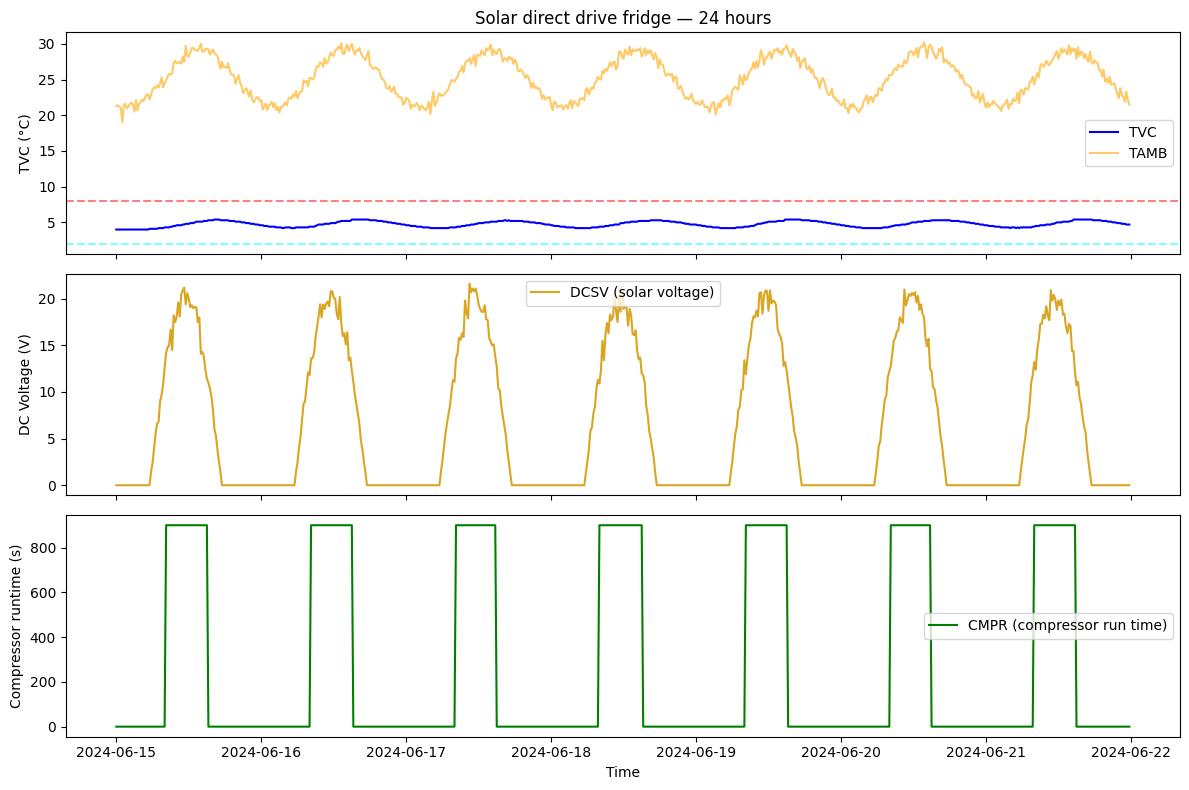

In [3]:
# Solar fridge at latitude 12
solar_config = default_config(power_type="solar", latitude=12.0)
solar_config.sample_interval = 900
sample_days = 7

solar_batch_size = int(86400 / solar_config.sample_interval * sample_days)  # * sample 7 days of data at 10-minute intervals

rs_solar = SimulatedRecordSet.generate(solar_config, batch_size=solar_batch_size, start_time=start, interval=solar_config.sample_interval)

times_s = [r['ABST'] for r in rs_solar.records]
tvcs_s = [r['TVC'] for r in rs_solar.records]
dcsvs = [r['DCSV'] for r in rs_solar.records]
tambs_s = [r['TAMB'] for r in rs_solar.records]
cmprs_s = [r['CMPR'] for r in rs_solar.records]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(times_s, tvcs_s, label='TVC', color='blue')
axes[0].plot(times_s, tambs_s, label='TAMB', color='orange', alpha=0.6)
axes[0].axhline(2, color='cyan', linestyle='--', alpha=0.5)
axes[0].axhline(8, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('TVC (°C)')
axes[0].set_title('Solar direct drive fridge — 24 hours')
axes[0].legend()

axes[1].plot(times_s, dcsvs, label='DCSV (solar voltage)', color='goldenrod')
axes[1].set_ylabel('DC Voltage (V)')
axes[1].legend()

axes[2].plot(times_s, cmprs_s, label='CMPR (compressor run time)', color='green')
axes[2].set_ylabel('Compressor runtime (s)')
axes[2].set_xlabel('Time')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Fault injection

Inject a compressor failure starting 8 hours into the simulation to see TVC excursion.

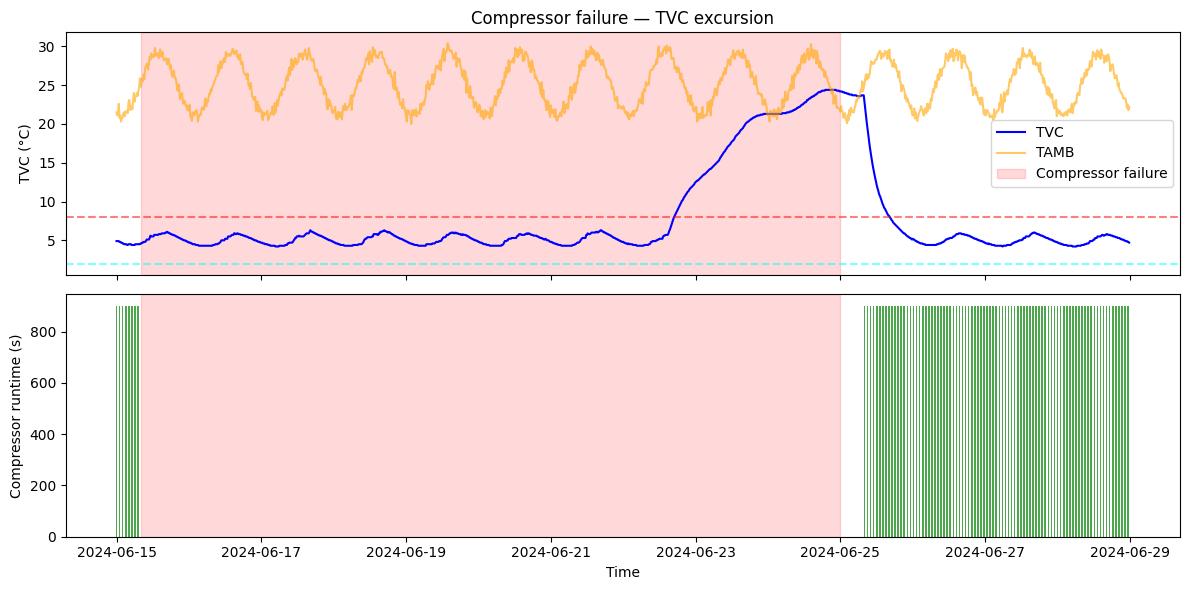

In [5]:
from utils.simulator.config import FaultType

fault_config = default_config(power_type="mains", latitude=12.0)
fault_config.sample_interval = 900
fault_config.fault.fault_type = FaultType.POWER_OUTAGE
fault_config.fault.fault_start_offset_s = 8 * 3600   # Fail at hour 8
fault_config.fault.fault_duration_s = 24 * 3600 * 10       # Lasts 6 hours

sample_days = 14
batch_size = int(86400 / fault_config.sample_interval * sample_days)  # * sample 7 days of data at 10-minute intervals
rs_fault = SimulatedRecordSet.generate(fault_config, batch_size=batch_size, start_time=start, interval=fault_config.sample_interval)

times_f = [r['ABST'] for r in rs_fault.records]
tvcs_f = [r['TVC'] for r in rs_fault.records]
cmprs_f = [r['CMPR'] for r in rs_fault.records]
tambs_f = [r['TAMB'] for r in rs_fault.records]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times_f, tvcs_f, label='TVC', color='blue')
axes[0].plot(times_f, tambs_f, label='TAMB', color='orange', alpha=0.6)
axes[0].axhline(2, color='cyan', linestyle='--', alpha=0.5)
axes[0].axhline(8, color='red', linestyle='--', alpha=0.5)
fault_start_time = start + dt.timedelta(hours=8)
fault_end_time = start + dt.timedelta(hours=24*10)
axes[0].axvspan(fault_start_time, fault_end_time, alpha=0.15, color='red', label='Compressor failure')
axes[0].set_ylabel('TVC (°C)')
axes[0].set_title('Compressor failure — TVC excursion')
axes[0].legend()

axes[1].bar(times_f, cmprs_f, width=dt.timedelta(minutes=8), color='green', alpha=0.7)
axes[1].axvspan(fault_start_time, fault_end_time, alpha=0.15, color='red')
axes[1].set_ylabel('Compressor runtime (s)')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

## 4. High-level: BaseRtmDevice

The `BaseRtmDevice` class wraps the simulator with device metadata and Pydantic schema validation. This is what `locustfile.py` uses.

In [9]:
# Create a virtual EMS device
config = MonitoringDeviceConfig(type='ems', upload_interval=3600, sample_interval=900)
device = BaseRtmDevice(config)
print(device)
print(f"Power source: {device.powersource}")
print(f"Facility: {device.config.facility.facility_name}")
print(f"Batch size per report: {device.config.batch_size}")

# Generate 3 sequential reports (simulating 3 upload cycles)
t = dt.datetime(2024, 6, 15, 6, 0, 0)
for i in range(3):
    report = device.create_report(report_time=t)
    print(f"\nReport {i+1} at {t}:")
    print(f"  Type: {type(report).__name__}")
    print(f"  Records: {len(report.records)}")
    for rec in report.records:
        print(f"    {rec.ABST} | TVC={rec.TVC:5.1f} | TAMB={rec.TAMB:5.1f}")
    t += dt.timedelta(hours=1)

BaseRtmDevice(type=ems, CID=NGA, AMFR=Qingdao Haier Biomedical Co., Ltd, AMOD=HTD-40, ASER=45b7f1acd674422d8d6eb889abd41a5d, ADOP=2019-08-14, LMFR=Qingdao Haier Biomedical Co., Ltd, LMOD=HTD-40, LSEV=0.1.x)
Power source: solar
Facility: Yar Akiya Basic Health Clinic
Batch size per report: 4

Report 1 at 2024-06-15 06:00:00:
  Type: EmsReport
  Records: 4
    2024-06-15 05:15:00 | TVC=  4.0 | TAMB= 22.1
    2024-06-15 05:30:00 | TVC=  4.0 | TAMB= 23.5
    2024-06-15 05:45:00 | TVC=  4.0 | TAMB= 22.8
    2024-06-15 06:00:00 | TVC=  4.1 | TAMB= 22.9

Report 2 at 2024-06-15 07:00:00:
  Type: EmsReport
  Records: 4
    2024-06-15 06:15:00 | TVC=  4.1 | TAMB= 23.4
    2024-06-15 06:30:00 | TVC=  4.1 | TAMB= 23.8
    2024-06-15 06:45:00 | TVC=  4.1 | TAMB= 24.0
    2024-06-15 07:00:00 | TVC=  4.1 | TAMB= 23.5

Report 3 at 2024-06-15 08:00:00:
  Type: EmsReport
  Records: 4
    2024-06-15 07:15:00 | TVC=  4.2 | TAMB= 23.6
    2024-06-15 07:30:00 | TVC=  4.2 | TAMB= 23.9
    2024-06-15 07:45:00

## 5. JSON serialization (CCDX format)

Reports serialize to the CCDX transfer schema, ready for POST to OpenFn.

In [7]:
import json
from utils.schemas import TransferMetadata, EmsTransfer
from utils.generator import transfer_metadata

config = MonitoringDeviceConfig(type='ems', upload_interval=3600, sample_interval=900)
device = BaseRtmDevice(config)
report = device.create_report(report_time=dt.datetime(2024, 6, 15, 12, 0, 0))

md = transfer_metadata(type='ems')
transfer = EmsTransfer(data=[report], meta=TransferMetadata(**md))
body = transfer.model_dump(mode='json', exclude_unset=True)

print(json.dumps(body, indent=2, default=str)[:2000])
print("...")

{
  "meta": {
    "transferId": "6ebd6bf4-414a-41ff-8184-52770e0bf41d",
    "transferSrc": "org.nhgh",
    "transferredAt": "2026-03-12T03:45:59.235911Z",
    "schemaVersion": "ems:1.0",
    "callbackUrl": null
  },
  "data": [
    {
      "ADOP": "2022-03-30",
      "AMFR": "Vestfrost Solutions",
      "AMOD": "VLS 026 RF SDD",
      "ASER": "e3561a82a5834a85b944d170c11eec11",
      "APQS": "E003/091",
      "CID": "NGA",
      "LDOP": "2022-03-30",
      "LMFR": "Vestfrost Solutions",
      "LMOD": "VLS 026 RF SDD",
      "LPQS": "E003/091",
      "LSER": "41ee68e774454ff1b1f8b6ad7b793ad6",
      "LSV": "0.1.x",
      "EDOP": "2022-03-30",
      "EMFR": "Vestfrost Solutions",
      "EMOD": "VLS 026 RF SDD",
      "EPQS": "E003/091",
      "ESER": "41ee68e774454ff1b1f8b6ad7b793ad6",
      "EMSV": "0.1.x",
      "records": [
        {
          "ABST": "20240615T111500Z",
          "BEMD": 14.5,
          "BLOG": 14.5,
          "CMPR": 0,
          "DORV": 0,
          "TAMB": 28.4,
 